In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [19]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from predict_angle_video import load_yolo_model, load_regression_model, load_lstm_model, apply_lstm_to_sequence, predict_angle
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

#load the models to process the video
# Load models
yolo_model = load_yolo_model()
regression_model, device = load_regression_model()
lstm_model, lstm_device = load_lstm_model()

Predictions saved to ../PatientsVideos/PPB_PDL002_V1_PS_R_right_predictions.json


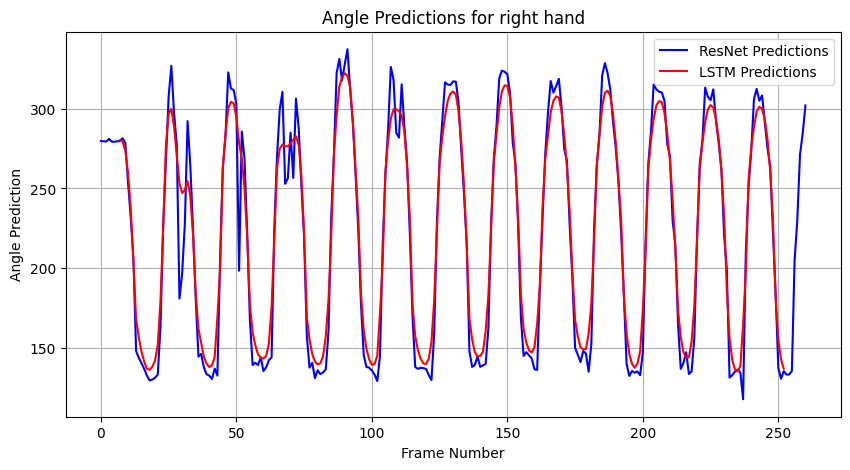

In [36]:
# Load the JSON file

FILEName = 'PPB_PDL002_V1_PS_R.mp4'

VIDEOFile = '../PatientsVideos/' + FILEName
JSONFile = '../PatientsVideos/'+FILEName[:-4]+'_task_data.json'

#read JSON file and get data related to subject position (bbox) and tasks start/end frames 
with open(JSONFile, 'r') as file:
    data = json.load(file)

# Get the data in "tasks"
tasks_data = data.get('tasks', [])
fps = data.get('fps', [])

initFrame = int(tasks_data[0]['start'] * fps)
endFrame = int(tasks_data[0]['end'] * fps)
hand = ('left' if '_L' in FILEName else 'right') 
bbox = [int(tasks_data[0]['x']), int(tasks_data[0]['y']), int(tasks_data[0]['width']), int(tasks_data[0]['height'])] #[x, y, width, height]



#load video and start predicting 
video = cv2.VideoCapture(VIDEOFile)
if not video.isOpened():
    print(f"Error: Could not open video {VIDEOFile}")
    video.release()
else:
    frame_id = 0
    frame_numbers = []
    resnet_predictions = []


    # Calculate the top-left and bottom-right coordinates of the bonding box to crop the subject from the image
    x1, y1 = bbox[0], bbox[1]
    x2, y2 = bbox[0] + bbox[2], bbox[1] + bbox[3]

    # Increase the bbox size by 10%
    width_increase = int(bbox[2] * 0.1)
    height_increase = int(bbox[3] * 0.1)

    # Update coordinates ensuring they are within frame boundaries
    x1_bodypose = max(0, int(x1 - width_increase // 2))
    y1_bodypose = max(0, int(y1 - height_increase // 2))
    x2_bodypose = min(int(video.get(cv2.CAP_PROP_FRAME_WIDTH)), int(x2 + width_increase // 2))
    y2_bodypose = min(int(video.get(cv2.CAP_PROP_FRAME_HEIGHT)), int(y2 + height_increase // 2))

    while video.isOpened():
        ret, frame = video.read()
        if not ret:
            break

        # Crop the frame to the bounding box
        cropped_frame = frame[y1_bodypose:y2_bodypose, x1_bodypose:x2_bodypose]

        # Run YOLO inference
        results = yolo_model(cropped_frame, verbose=False)

        # Filter detections based on the specified hand
        if hand == 'left':
            hand_detections = [d for d in results[0].boxes if int(d.cls) == 0]
        else:
            hand_detections = [d for d in results[0].boxes if int(d.cls) == 1]

        # Get the highest confidence detection for the specified hand
        best_hand = max(hand_detections, key=lambda x: x.conf) if hand_detections else None

        # Predict angles using ResNet
        if best_hand:
            hand_box = best_hand.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = map(int, hand_box[:4])
            hand_crop = cropped_frame[y1:y2, x1:x2]
            angle = predict_angle(hand_crop, regression_model, transform, device)
            resnet_predictions.append(angle)
        else:
            resnet_predictions.append(None)

        frame_numbers.append(frame_id)
        frame_id += 1

    video.release()

    # Apply LSTM model to refine predictions
    lstm_predictions = apply_lstm_to_sequence(resnet_predictions, lstm_model, lstm_device)
    #adjust LSTM predictions to match the length of frame_numbers
    lstm_predictions = [None] * 7 + lstm_predictions[:len(frame_numbers) - 7]

    time = list(np.linspace(0, (len(frame_numbers)-1)*(1/fps), len(frame_numbers)))
    # Save predictions to JSON
    output_path = os.path.join('../PatientsVideos/', f"{FILEName[:-4]}_{hand}_predictions.json")
    with open(output_path, 'w') as f:
        json.dump({"frame_numbers": frame_numbers, "resnet_predictions": resnet_predictions, "lstm_predictions": lstm_predictions, "time": time}, f)
    print(f"Predictions saved to {output_path}")

    # # Plot and save predictions
    plt.figure(figsize=(10, 5))
    plt.plot(frame_numbers, resnet_predictions, label='ResNet Predictions', color='blue')
    plt.plot(frame_numbers, lstm_predictions, label='LSTM Predictions', color='red')
    plt.xlabel('Frame Number')
    plt.ylabel('Angle Prediction')
    plt.title(f'Angle Predictions for {hand} hand')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join('../PatientsVideos/', f"{FILEName[:-4]}_{hand}_predictions.png"))
    plt.show()


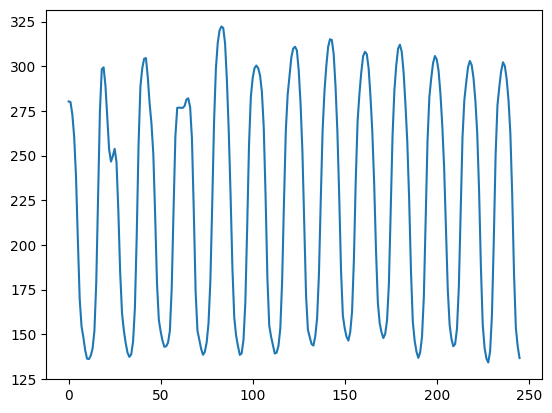

In [42]:
from scipy.signal import butter, filtfilt

# Define the low pass filter
def low_pass_filter(data, cutoff=10, fs=30, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

# Filter out None values from lstm_predictions
filtered_lstm_predictions = [x for x in lstm_predictions if x is not None]

# Apply the low pass filter to the filtered lstm_predictions
filtered_lstm_predictions = low_pass_filter(filtered_lstm_predictions)
plt.plot(filtered_lstm_predictions)